Problem Statement:
    This objective of this project is to understand how student' test scores are affected by features such as parent's level of education, gender, ethnicity, test preparation materials and lunch.

Data Source
https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetid=74977
-dataset is comprised of 1000 rows and 8 columns

In [4]:
### Import Pandas, Numpy, Matplotlib, Seaborn and Warning Library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [5]:
# Import dataset csv as Pandas DataFrame
df = pd.read_csv('stud.csv')

In [6]:
# Display the first 5 rows of the DataFrame
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
# View shape of the DataFrame
df.shape

(1000, 8)

In [22]:
# Display the data types of each column in the DataFrame and check for Null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [20]:
#Check for missing values in the DataFrame
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [21]:
#Check for duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(0)

In [24]:
#Check dataset statistics and distribution of the numberic data
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Means and standard deviations are all approximately the same for all three test score types. The minimum is across all three test score types does vary with scores of 0, 17 and 15. 

In [27]:
#Enumerate the number of object type and integer type columns in the DataFrame
object_columns = df.select_dtypes(include='object').columns
int_columns = df.select_dtypes(include='int64').columns
print(f"The dataset has {len(object_columns)} object type columns and {len(int_columns)} integer type columns.")

The dataset has 5 object type columns and 3 integer type columns.


In [28]:
# Display the unique values and their counts for each object type column in the DataFrame
for data_type in object_columns:
    print(f"Column: {data_type}, Unique Value Count: {df[data_type].nunique()} \n Unique Values: {df[data_type].unique()}")
for data_type in int_columns:
    print(f"Column: {data_type}, Unique Value Count: {df[data_type].nunique()}")

Column: gender, Unique Value Count: 2 
 Unique Values: ['female' 'male']
Column: race_ethnicity, Unique Value Count: 5 
 Unique Values: ['group B' 'group C' 'group A' 'group D' 'group E']
Column: parental_level_of_education, Unique Value Count: 6 
 Unique Values: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Column: lunch, Unique Value Count: 2 
 Unique Values: ['standard' 'free/reduced']
Column: test_preparation_course, Unique Value Count: 2 
 Unique Values: ['none' 'completed']
Column: math_score, Unique Value Count: 81
Column: reading_score, Unique Value Count: 72
Column: writing_score, Unique Value Count: 77


In [29]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [33]:
#Add columns for total test score and average test score
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333


In [37]:
reading_full = df[df['reading_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()
math_full = df[df['math_score'] == 100]['average_score'].count()

print(f'Number of students with full marks in Math: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Math: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [36]:
read_less_20 = df[df['reading_score'] <= 20]['average_score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average_score'].count()
math_less_20 = df[df['math_score'] <= 20]['average_score'].count()

print(f'Number of students with less than or equal to 20 marks in Math: {math_less_20}')
print(f'Number of students with less than or equal to 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than or equal to 20 marks in Reading: {read_less_20}')

Number of students with less than or equal to 20 marks in Math: 4
Number of students with less than or equal to 20 marks in Writing: 3
Number of students with less than or equal to 20 marks in Reading: 1


At this stage we can see students are performing the worst in math and the best in reading. 

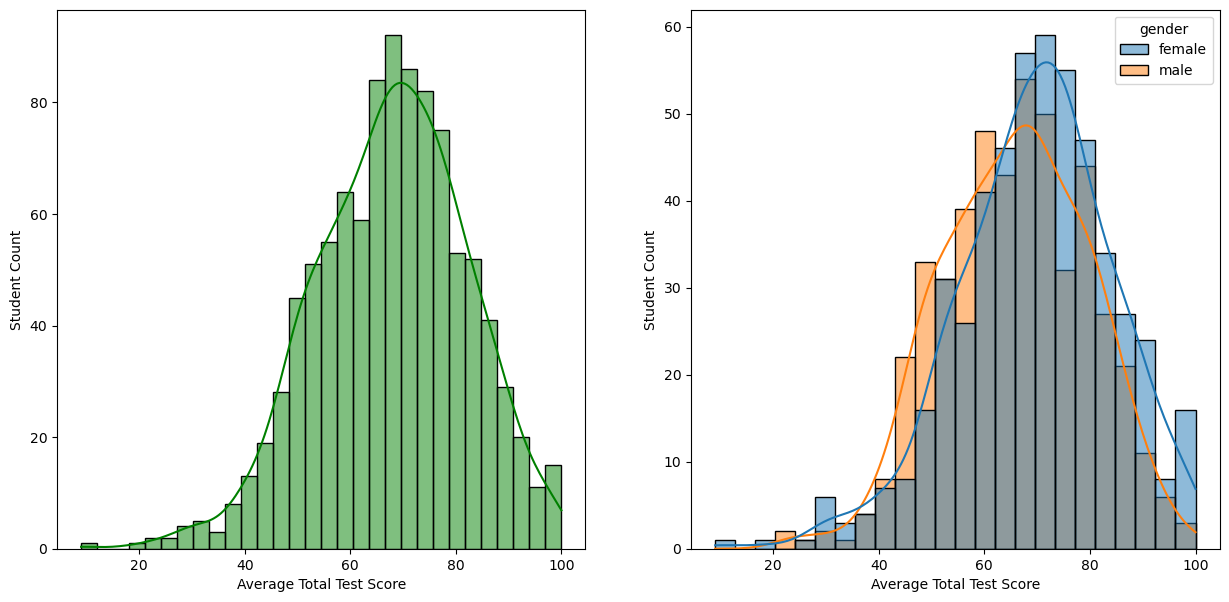

In [41]:
#Create a histogram with KDE (kernel density estimate) plot to visualize the distribution of the average test scores
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='g')
plt.xlabel('Average Total Test Score')
plt.ylabel('Student Count')
plt.subplot(122)
sns.histplot(data=df,x='average_score',kde=True,hue='gender')
plt.xlabel('Average Total Test Score')
plt.ylabel('Student Count')
plt.show()

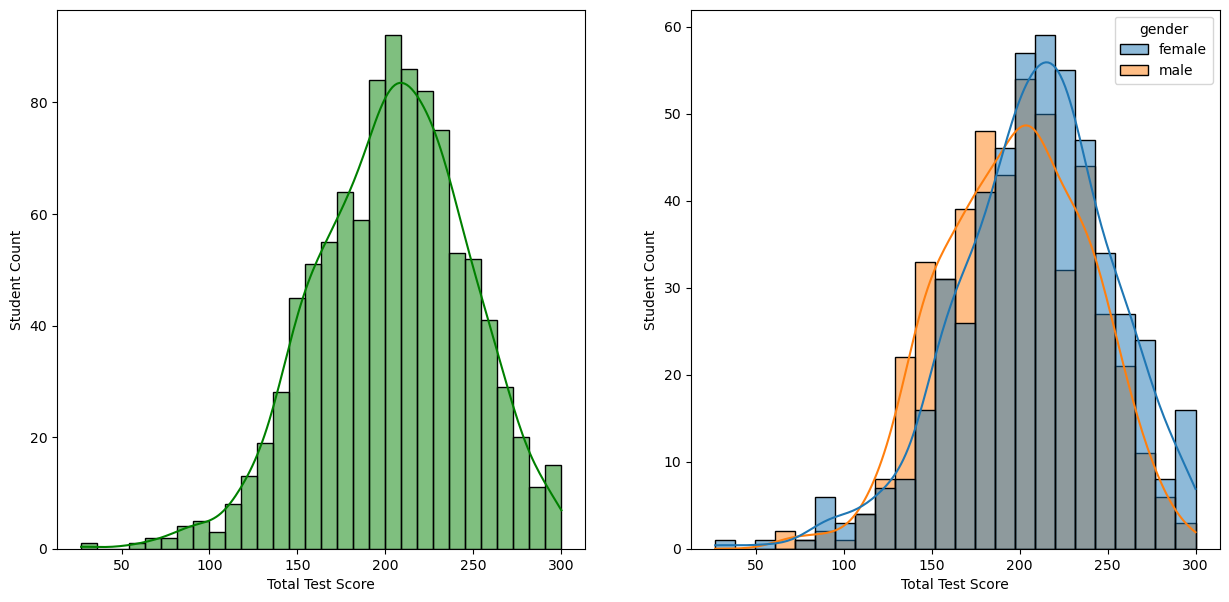

In [42]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total_score',bins=30,kde=True,color='g')
plt.xlabel('Total Test Score')
plt.ylabel('Student Count')
plt.subplot(122)
sns.histplot(data=df,x='total_score',kde=True,hue='gender')
plt.xlabel('Total Test Score')
plt.ylabel('Student Count')
plt.show()

Female students tend to perform better than male students in this dataset.

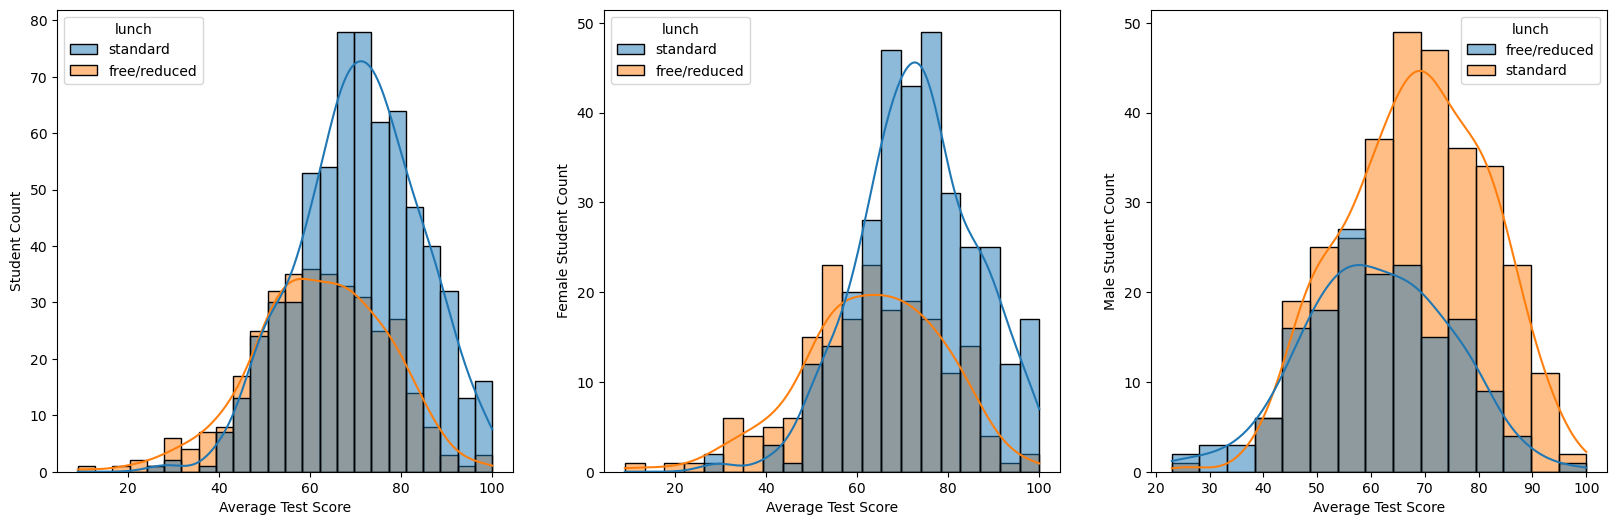

In [47]:
plt.subplots(1,3,figsize=(20,6))
plt.subplot(131)
sns.histplot(data=df,x='average_score',kde=True,hue='lunch')
plt.xlabel('Average Test Score')
plt.ylabel('Student Count')
plt.subplot(132)
sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='lunch')
plt.xlabel('Average Test Score')
plt.ylabel('Female Student Count')
plt.subplot(133)
sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='lunch')
plt.xlabel('Average Test Score')
plt.ylabel('Male Student Count')
plt.show()

Standard lunch seems to be associated with better test scores independant of gender.

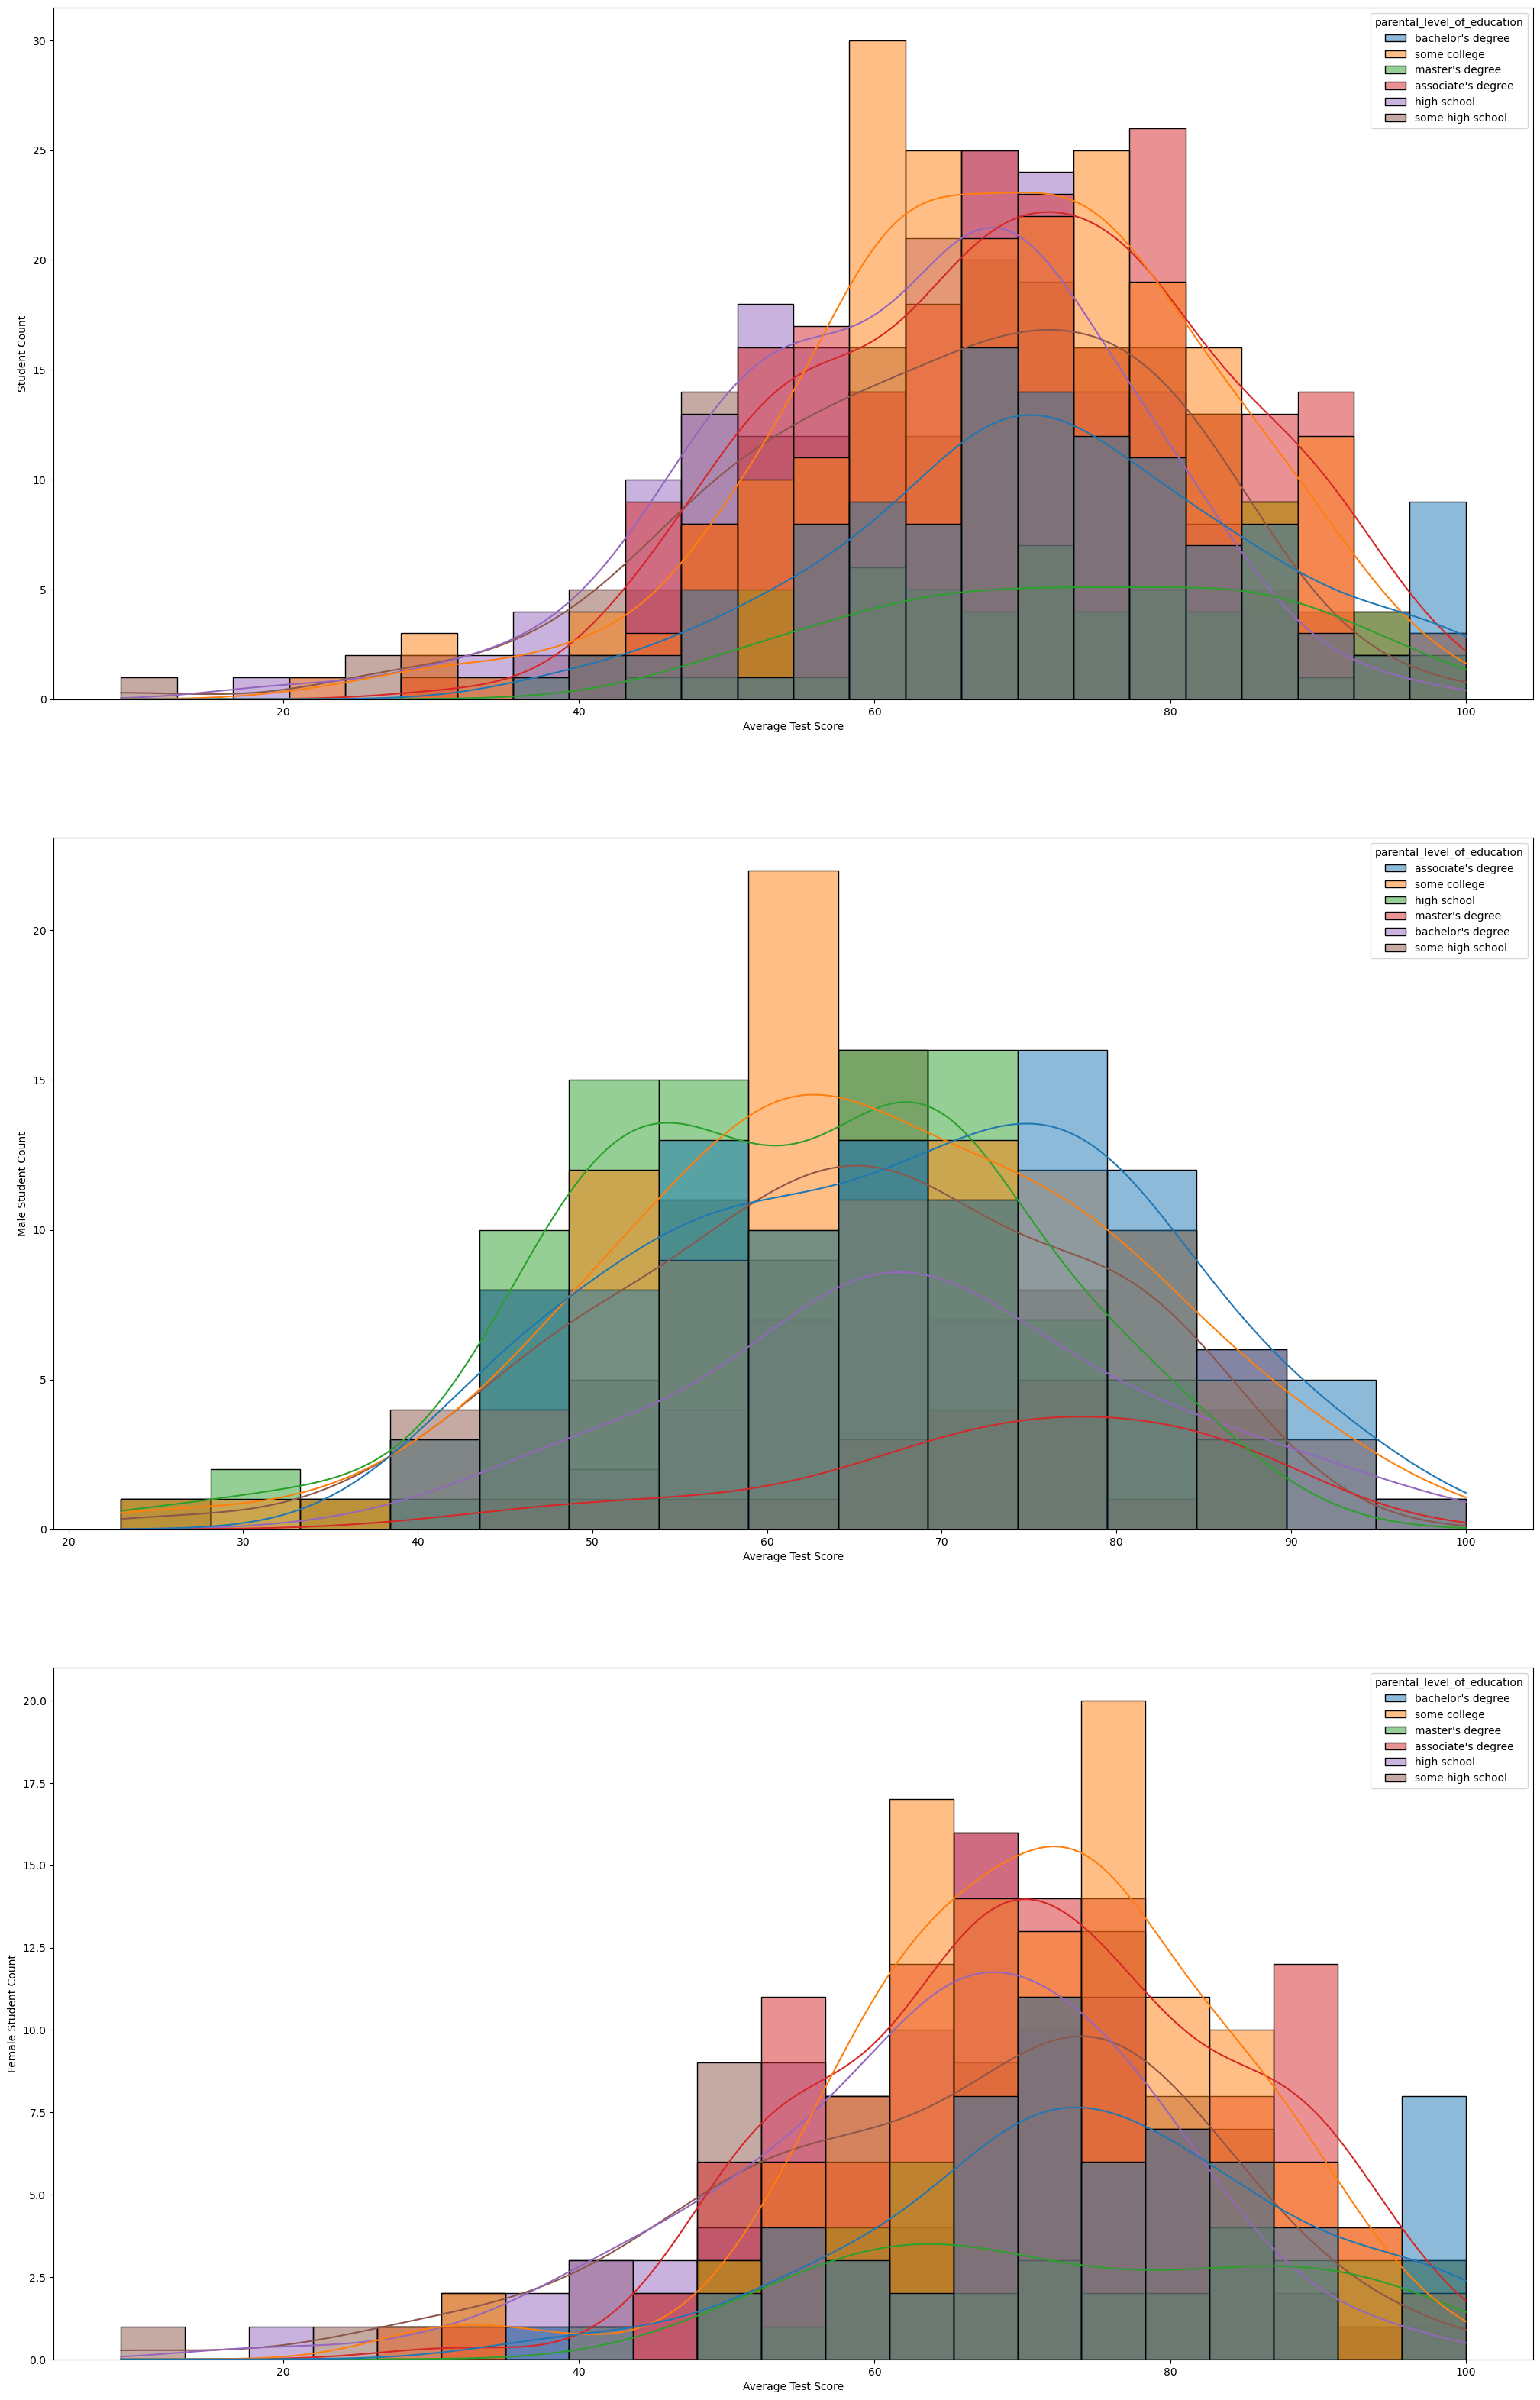

In [55]:
plt.subplots(3,1,figsize=(25,40))
plt.subplot(311)
ax =sns.histplot(data=df,x='average_score',kde=True,hue='parental_level_of_education')
plt.xlabel('Average Test Score')
plt.ylabel('Student Count')
plt.subplot(312)
ax =sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='parental_level_of_education')
plt.xlabel('Average Test Score')
plt.ylabel('Male Student Count')
plt.subplot(313)
ax =sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='parental_level_of_education')
plt.xlabel('Average Test Score')
plt.ylabel('Female Student Count')
plt.show()

In general, the parental level of education does not help students perform well on exams. The second plot indicates that male students with parents who have a master's or associate's degree tend to perform well on exams. For female students there is no distiguishable trend between parent education and test performance.

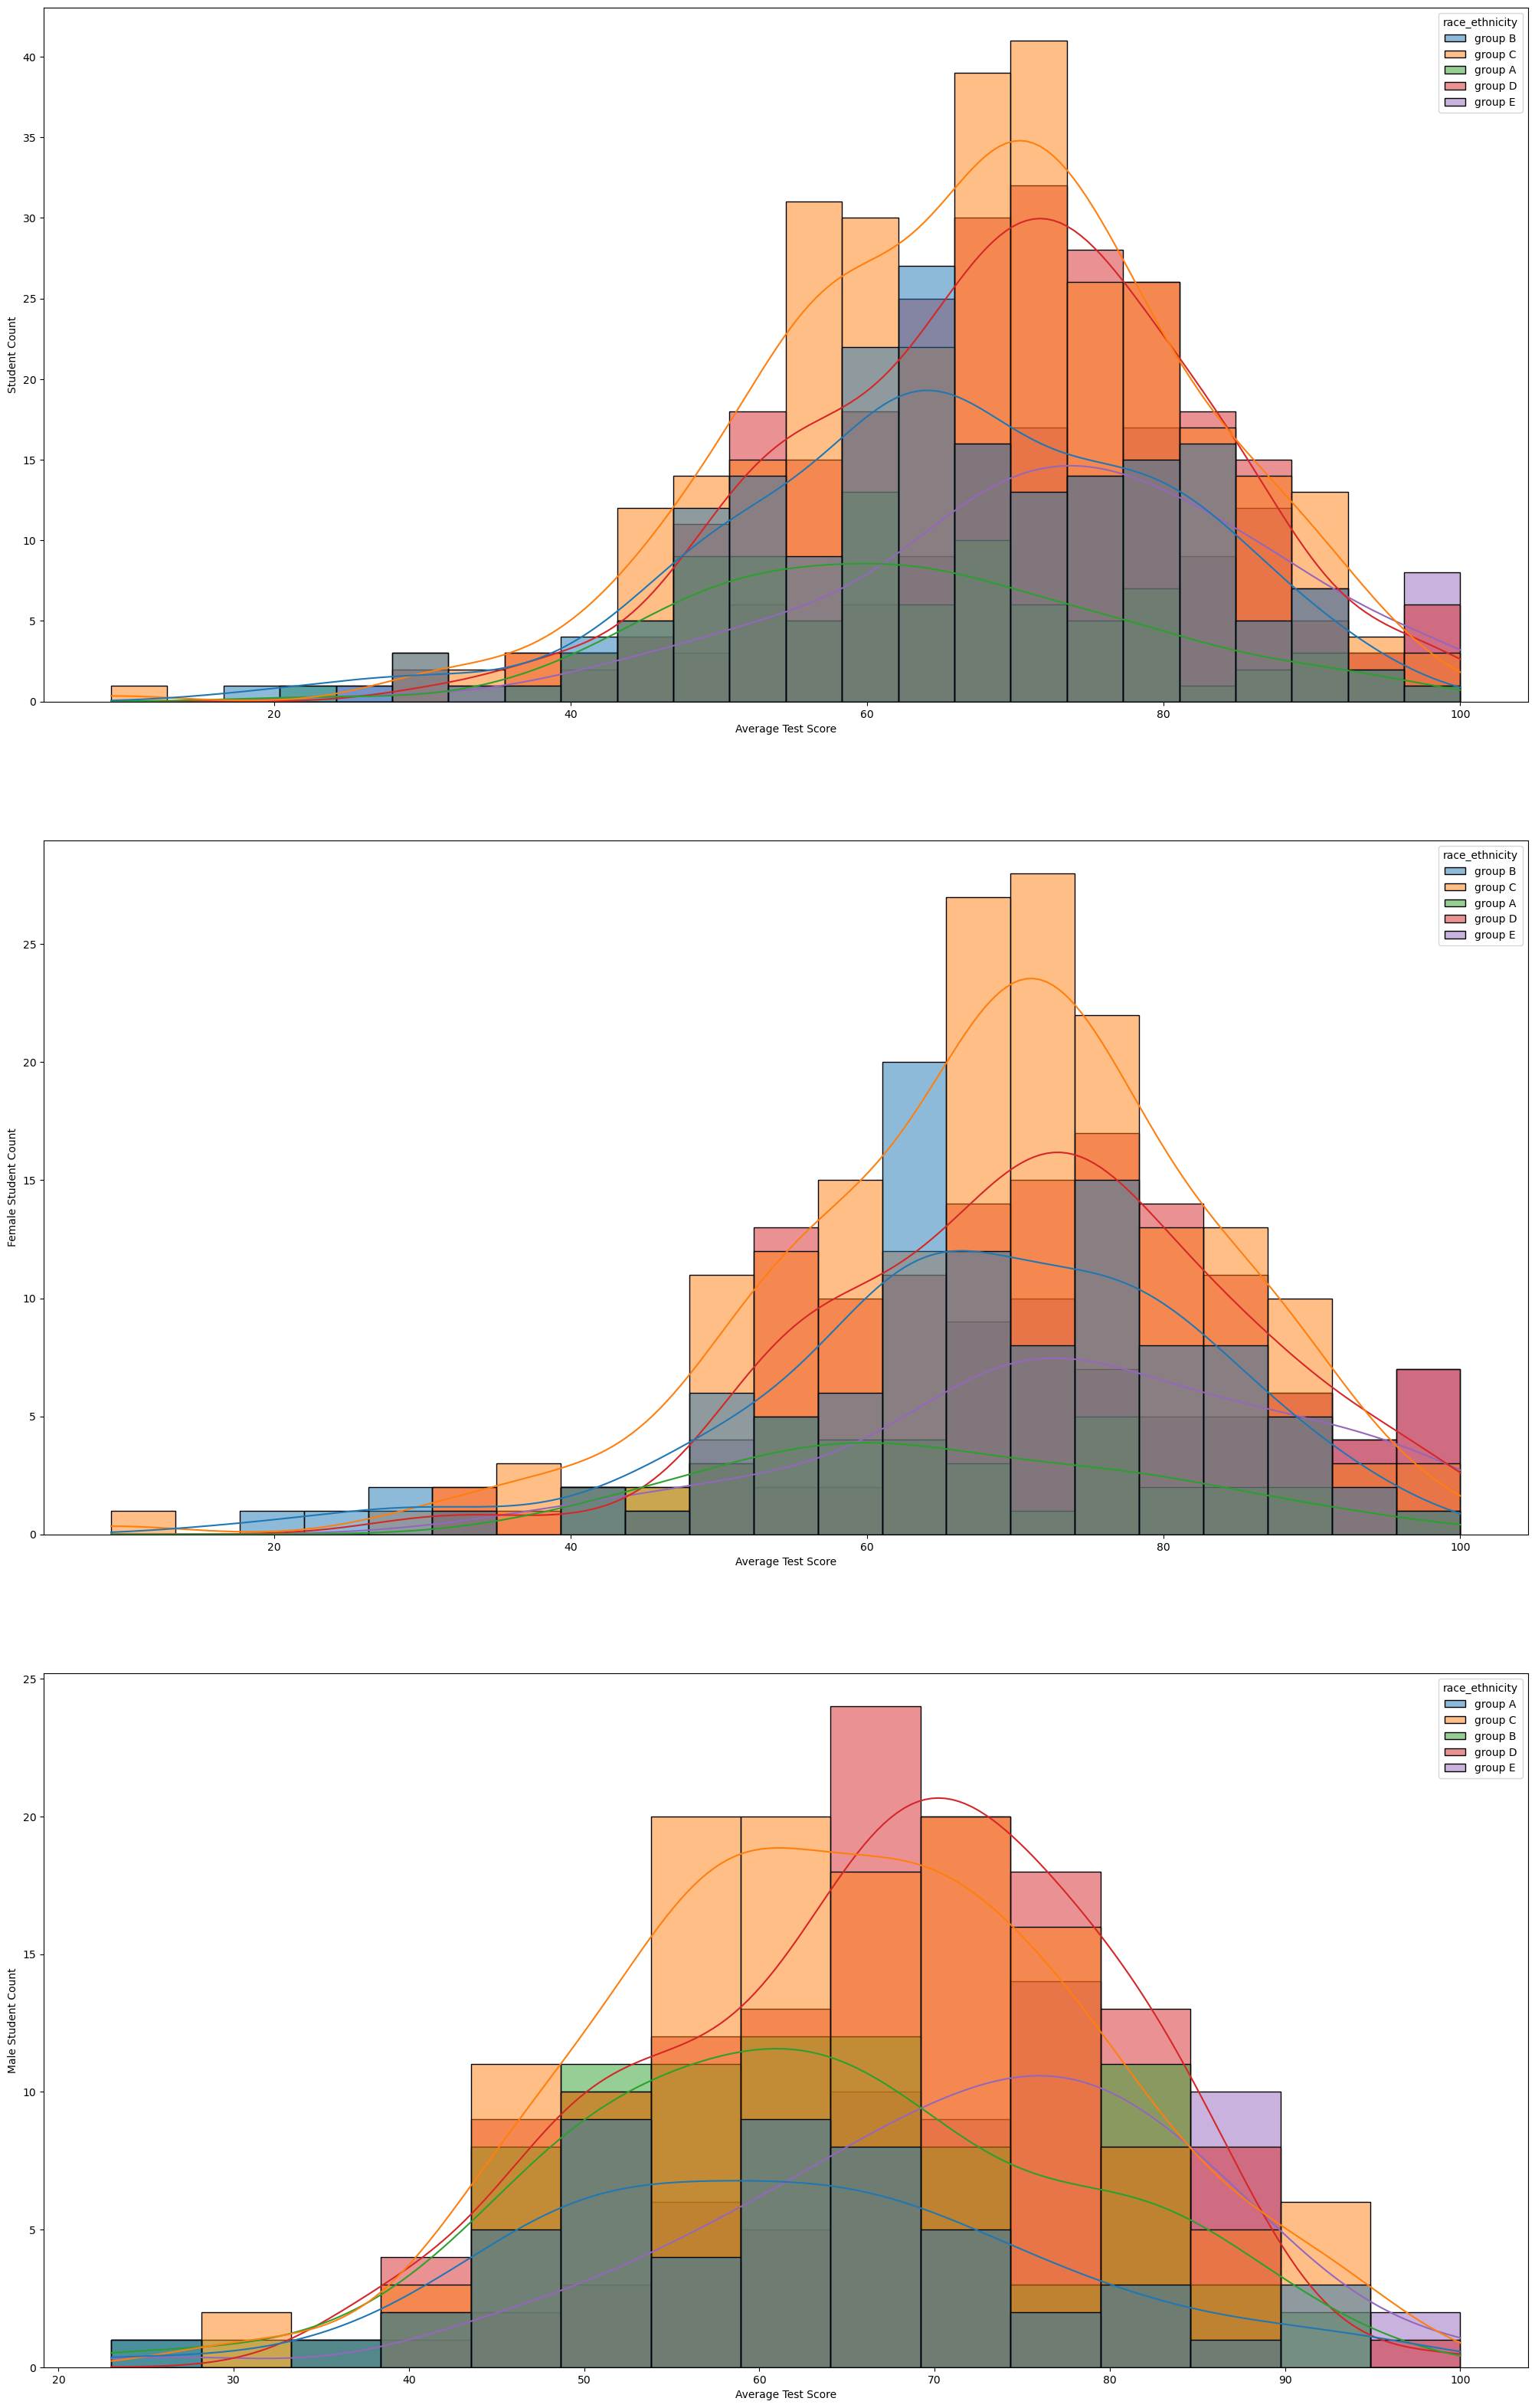

In [60]:
plt.subplots(3,1,figsize=(25,40))
plt.subplot(311)
ax =sns.histplot(data=df,x='average_score',kde=True,hue='race_ethnicity')
plt.xlabel('Average Test Score')
plt.ylabel('Student Count')
plt.subplot(312)
ax =sns.histplot(data=df[df.gender=='female'],x='average_score',kde=True,hue='race_ethnicity')
plt.xlabel('Average Test Score')
plt.ylabel('Female Student Count')
plt.subplot(313)
ax =sns.histplot(data=df[df.gender=='male'],x='average_score',kde=True,hue='race_ethnicity')
plt.xlabel('Average Test Score')
plt.ylabel('Male Student Count')
plt.show()

Students from group A and group B tend to perform poorly on exams independent of gender. 

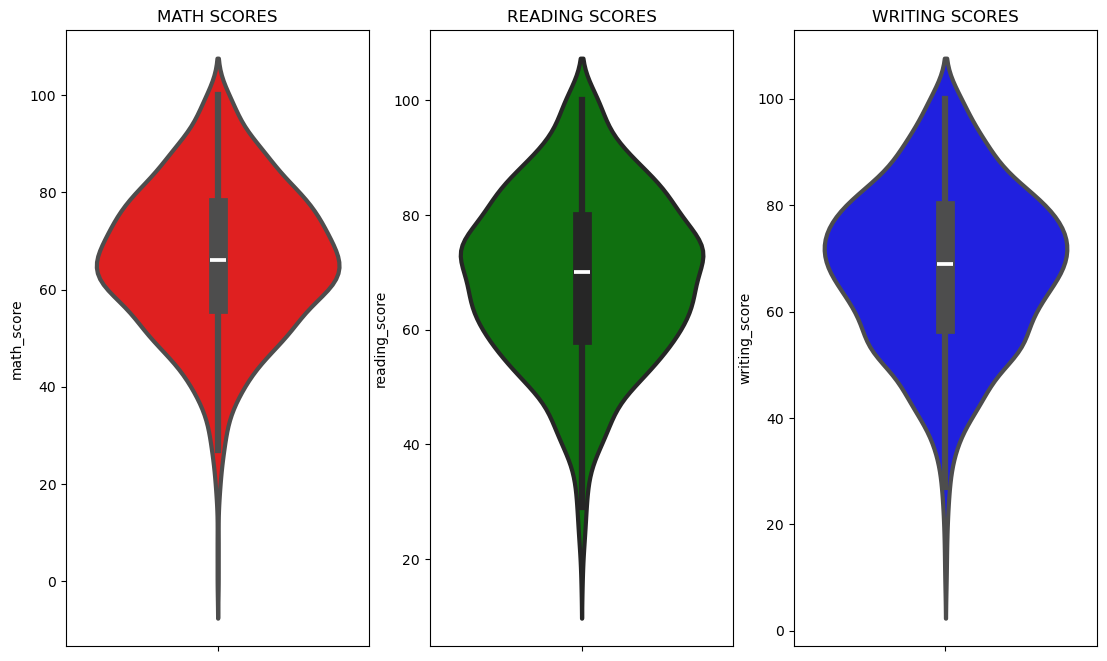

In [62]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

The above plots show that the majority of students score between 60 and 80 on math tests while the majority of students score between 50 and 80 on reading and writing tests. 

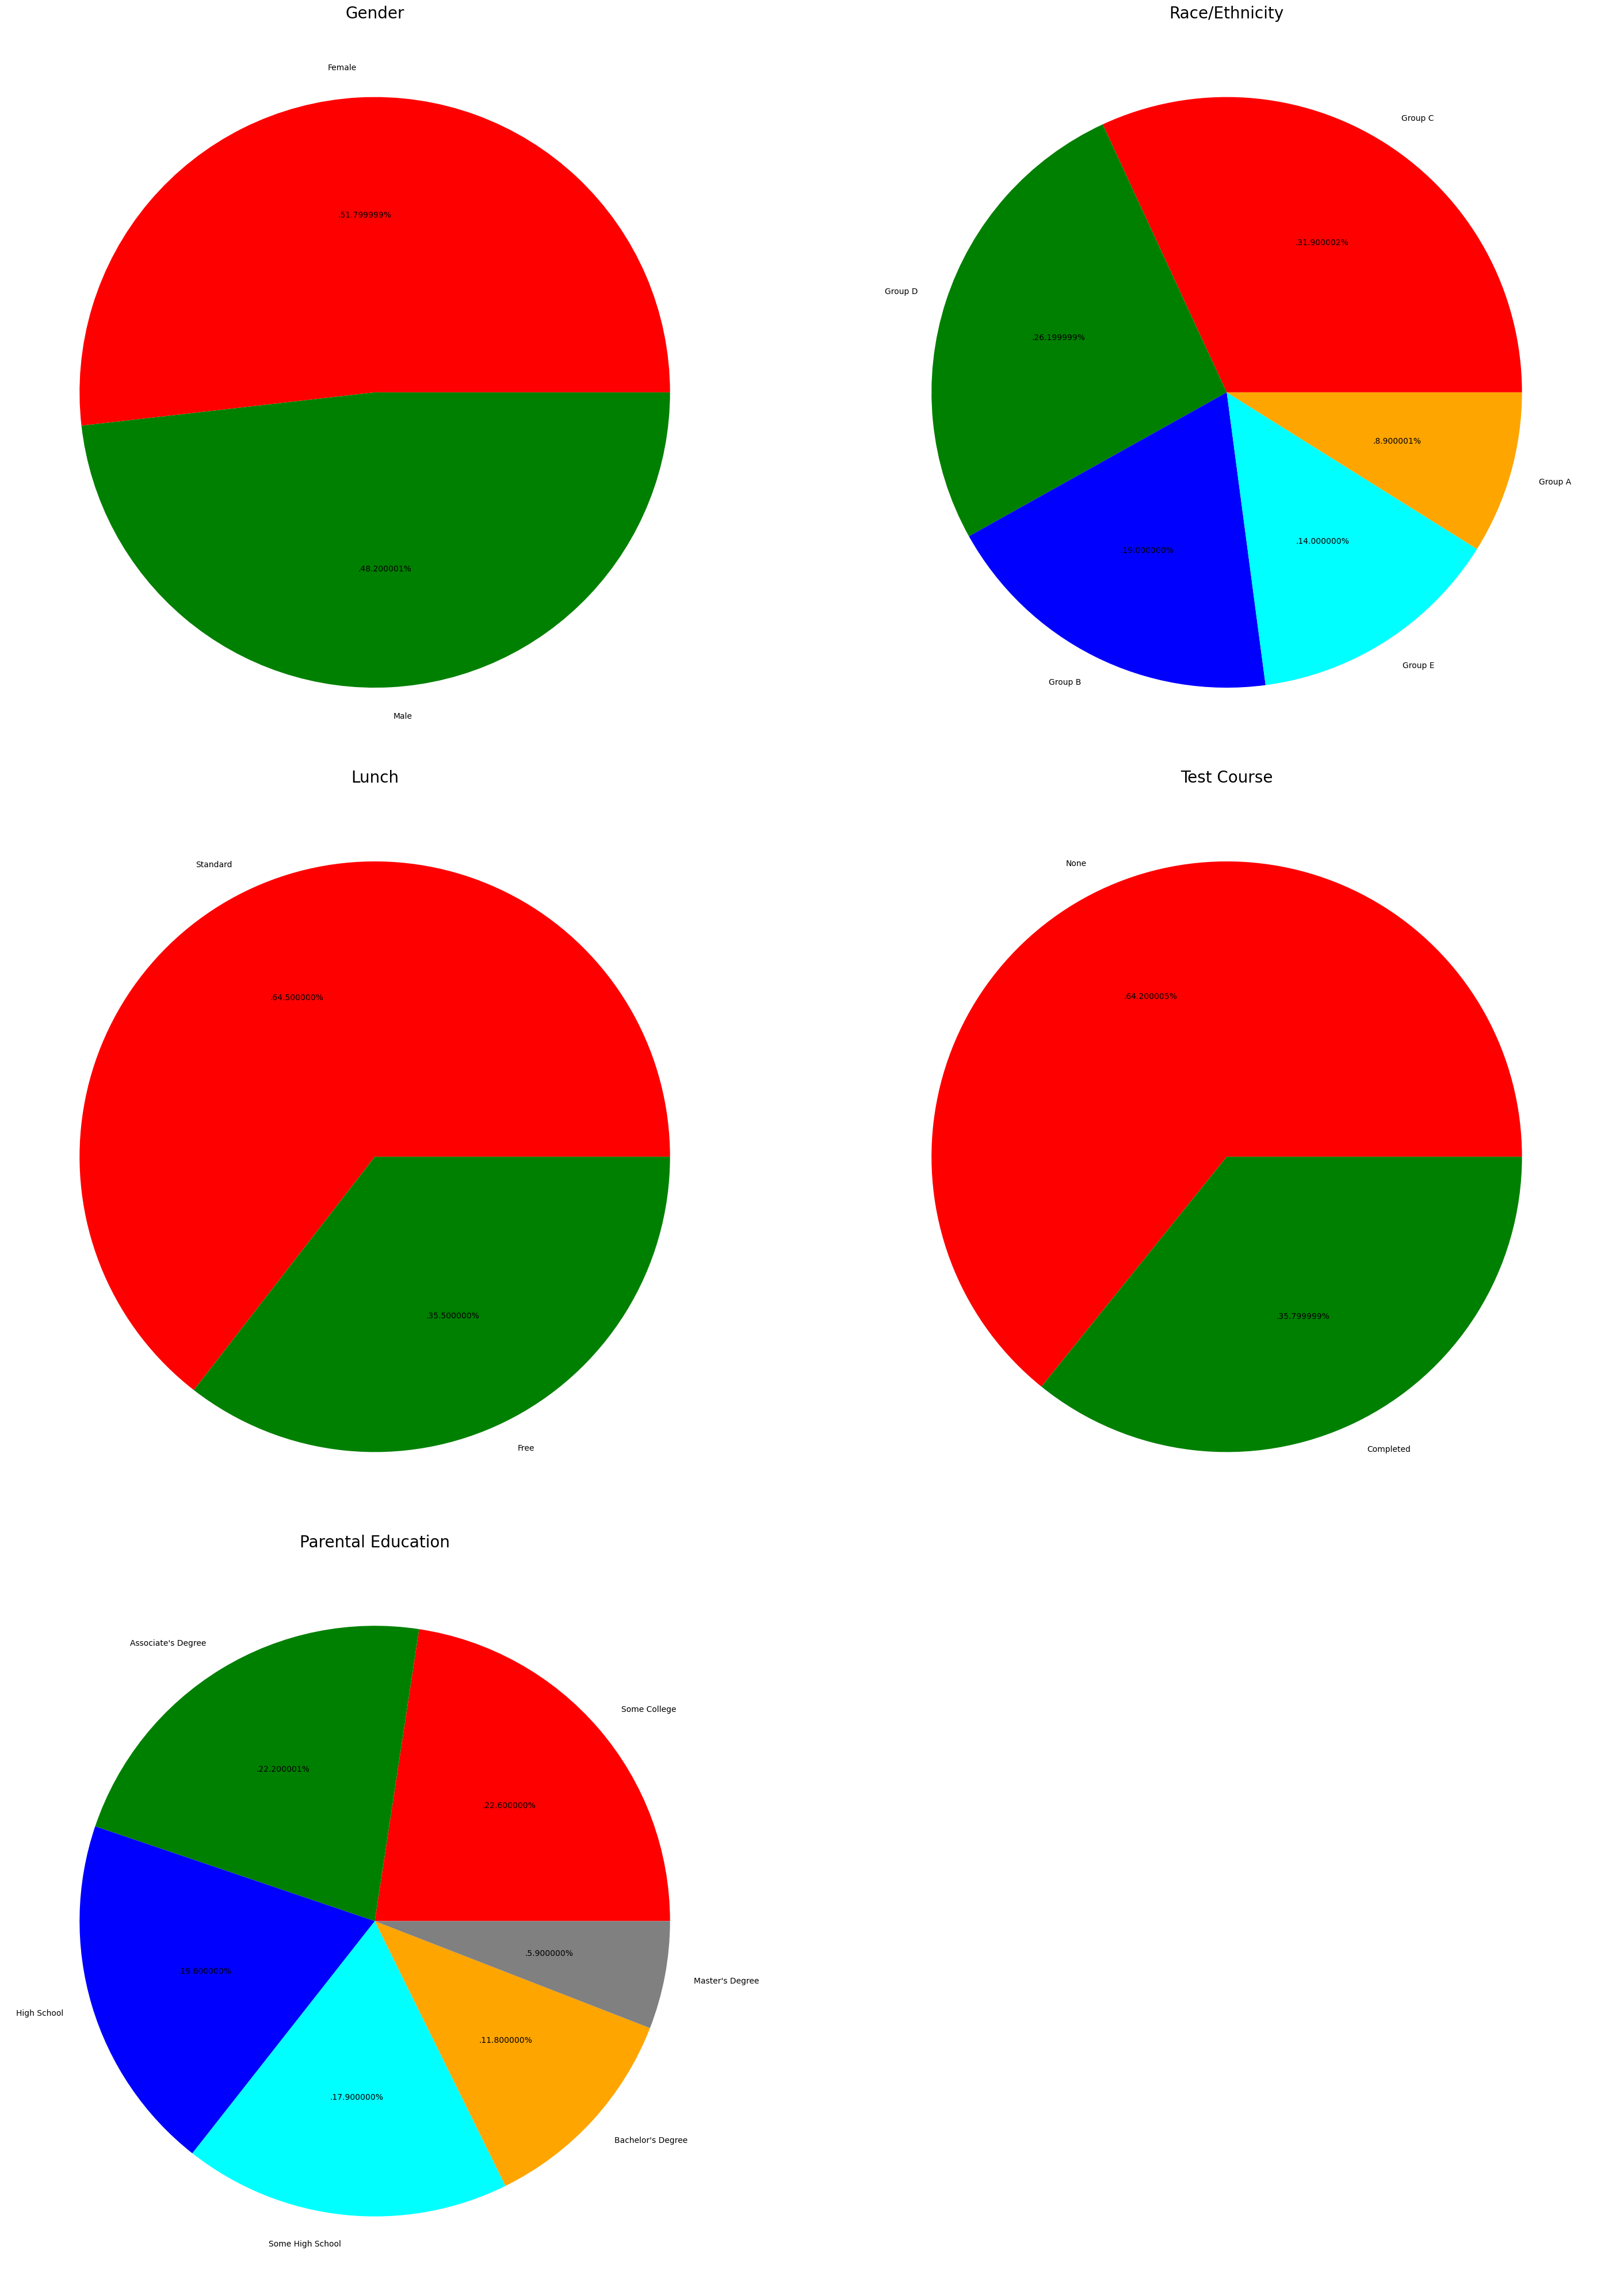

In [66]:
#Multivariate analysis using pie charts to visualize the distribution of categorical variables in the dataset
plt.rcParams['figure.figsize'] = (30,40)

plt.subplot(3, 2, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(3, 2, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race/Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(3, 2, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(3, 2, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(3, 2, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

- The number of male students is approximatley equal to female students
- The more students belong to group C than any other group
- The number of students that have standard lunch is greater
- The number of students who have not enrolled in any test prepartion course is greater
-The number of studens whose parental education is "Some College" is greatests, followed closely by "Associate's Degree"

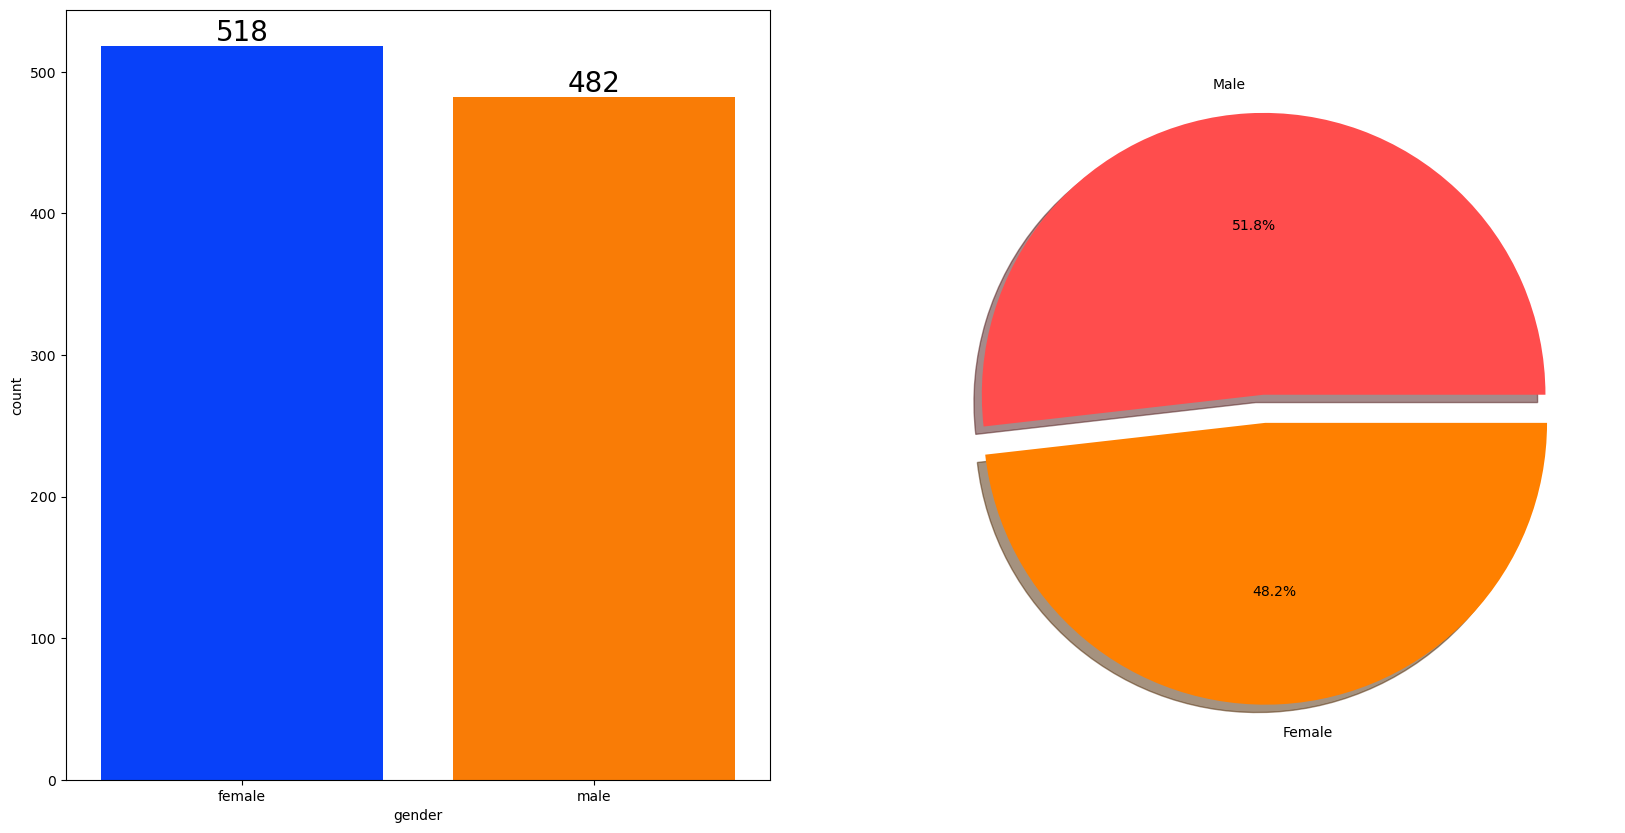

In [67]:
#Univarite Analysis of Gender
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

Gender data is balanced, with female students making up 48% (518 students) and males making up 52% (482 students) of the total student data population.

In [76]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total_score,average_score
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


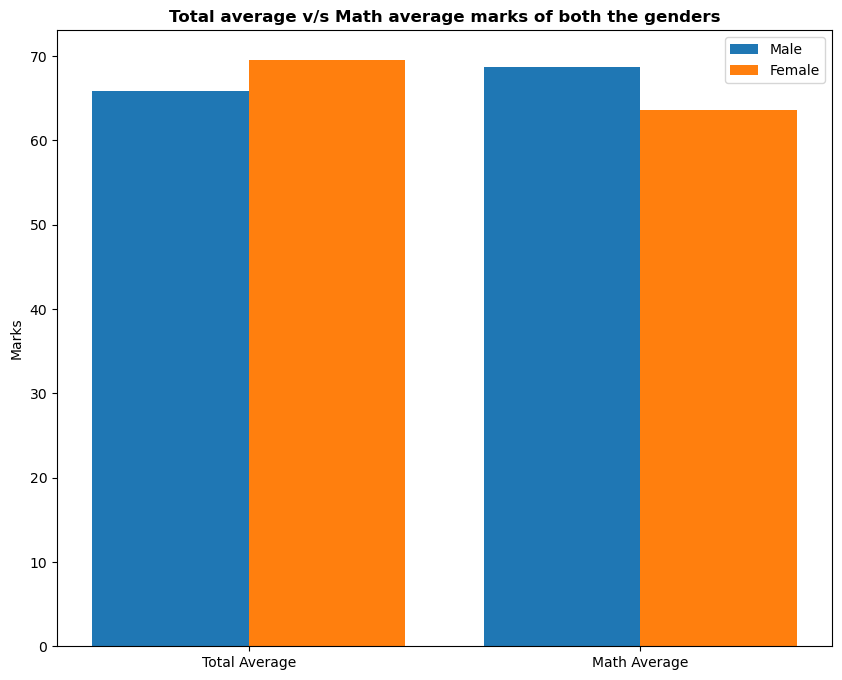

In [77]:
#Bivariate analysis of gender on test scores to identify if gender has an impact on the test scores of students.
plt.figure(figsize=(10, 8))

X = ['Total Average','Math Average']


female_scores = [gender_group['average_score'][0], gender_group['math_score'][0]]
male_scores = [gender_group['average_score'][1], gender_group['math_score'][1]]

X_axis = np.arange(len(X))
  
plt.bar(X_axis - 0.2, male_scores, 0.4, label = 'Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label = 'Female')
  
plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average v/s Math average marks of both the genders", fontweight='bold')
plt.legend()
plt.show()

On average females have a better overall score compared to male students. Males have a higher overall math average for this dataset. 

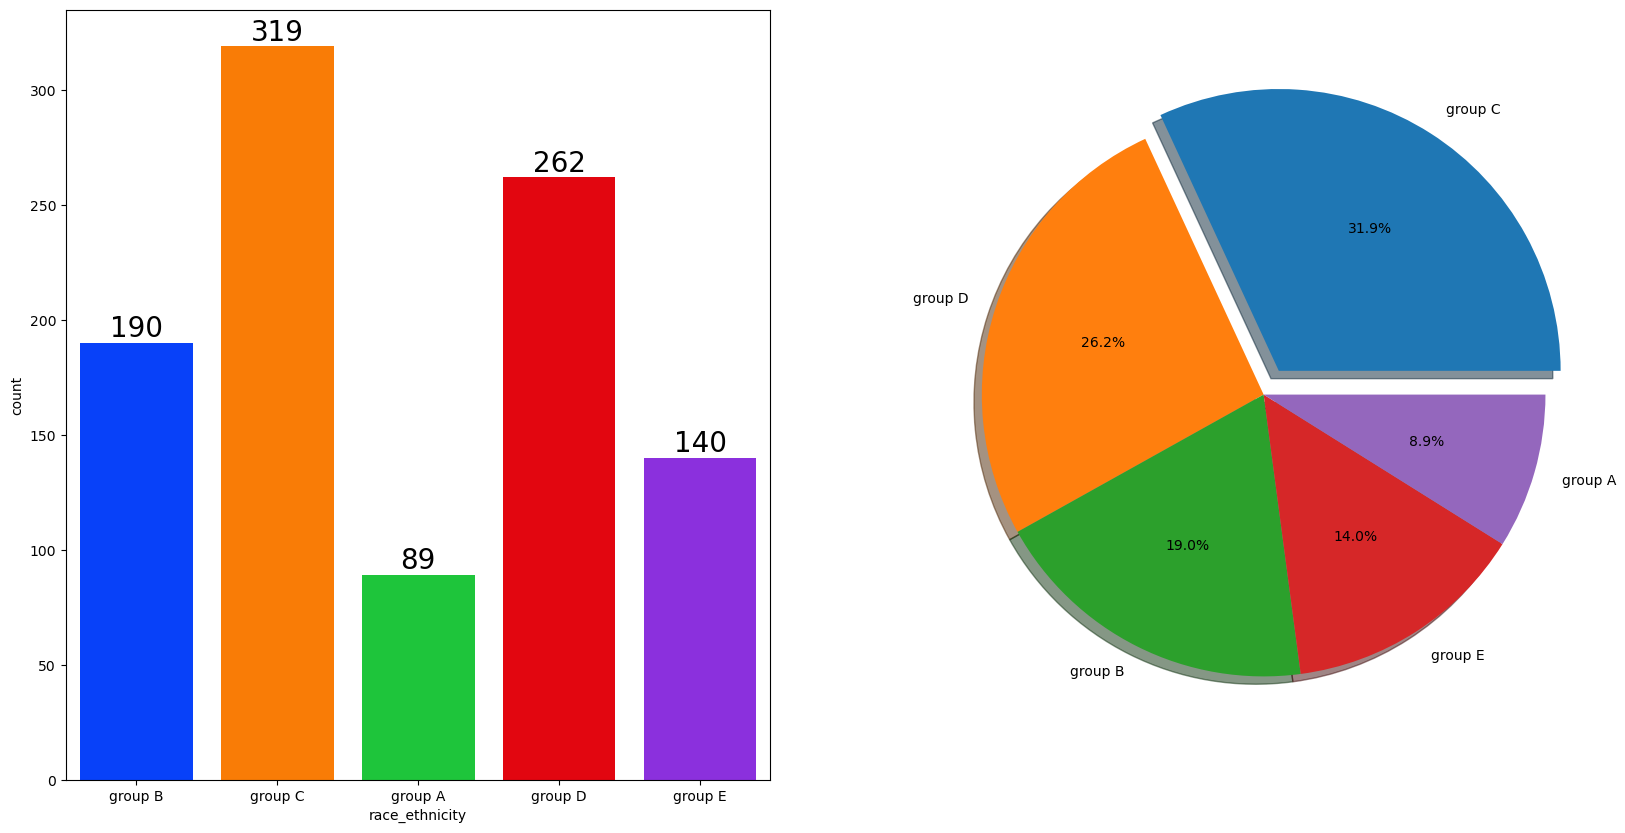

In [79]:
#Univariate analysis of race/ethnicity on test scores
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()  

-Most students belong to group C, closely followed by group D
-The smallest number of students belong to group A

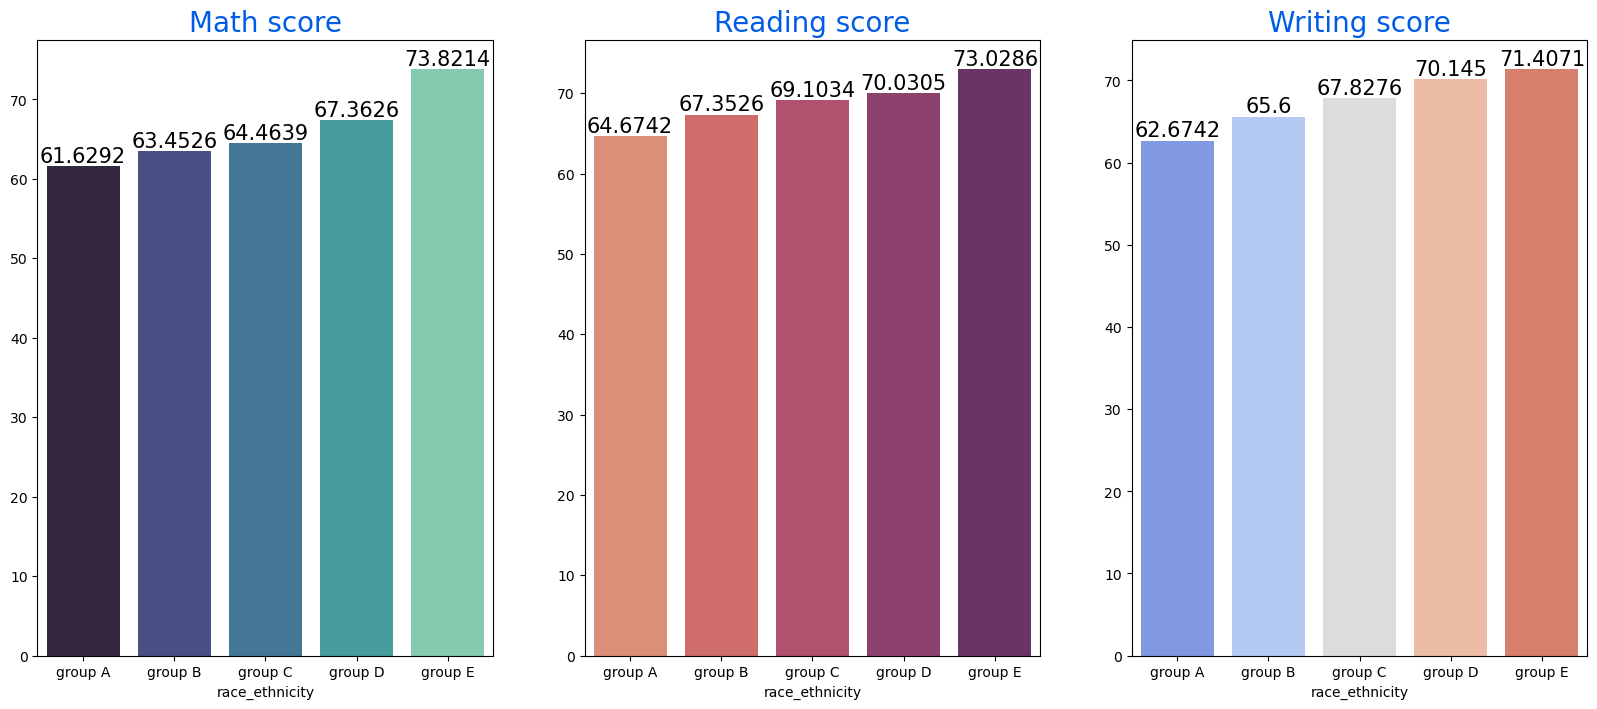

In [81]:
#Bivariate analysis of Gender and Race/Ethnicity
Group_data2=df.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0])
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

-Students belonging to group E tend to have higher test scores in all categories on average
-Students belonging to group A tend to have lower tests scores than any other gorup on average

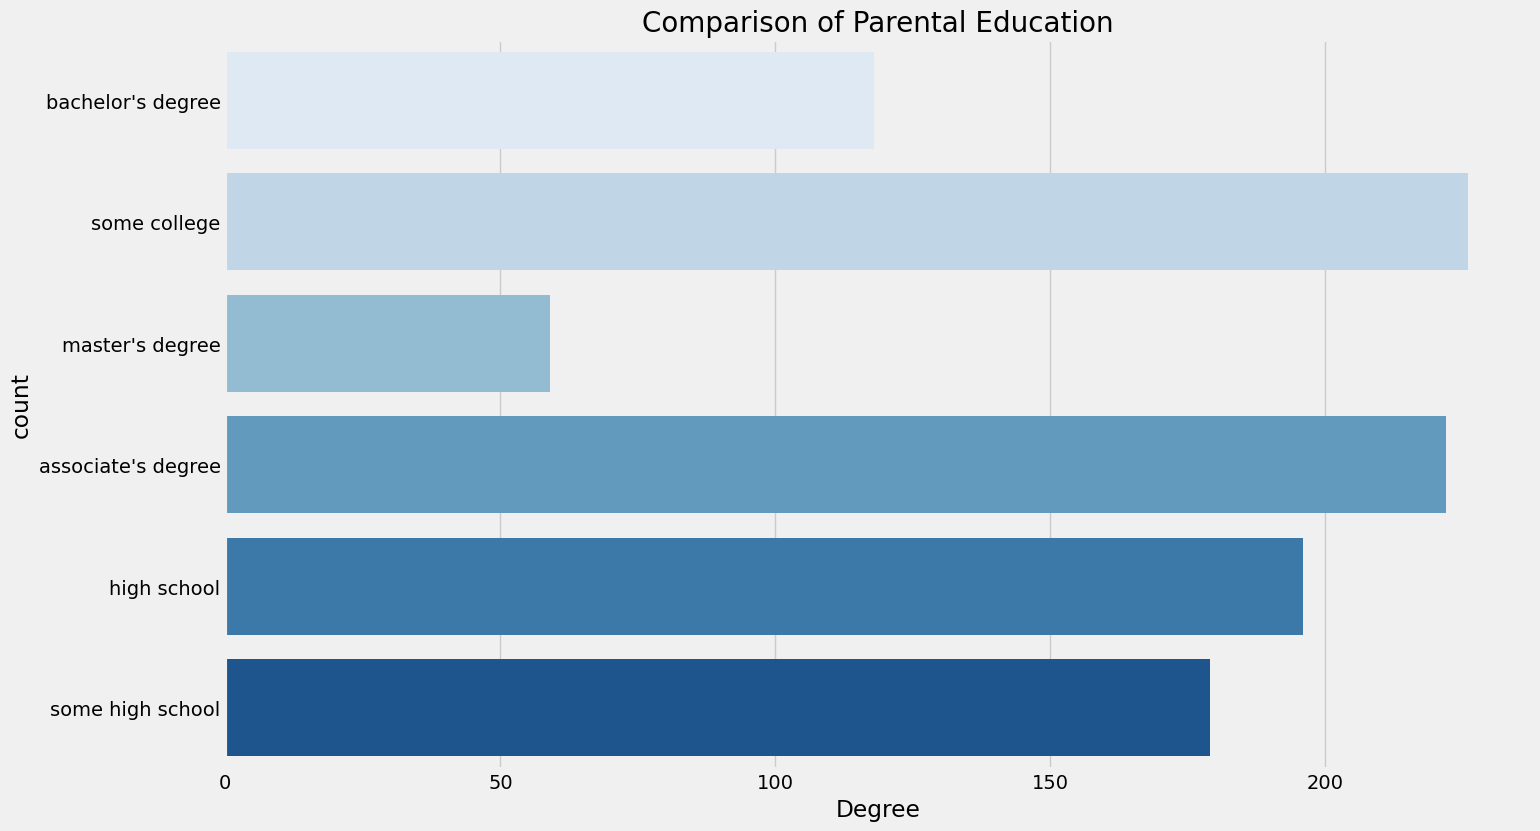

In [82]:
#Univariate analysis of parental level of education to identify the distribution of parental education levels in the dataset.
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('fivethirtyeight')
sns.countplot(df['parental_level_of_education'], palette = 'Blues')
plt.title('Comparison of Parental Education', fontweight = 30, fontsize = 20)
plt.xlabel('Degree')
plt.ylabel('count')
plt.show()

-The largest number of parents belong to the "Some College" group

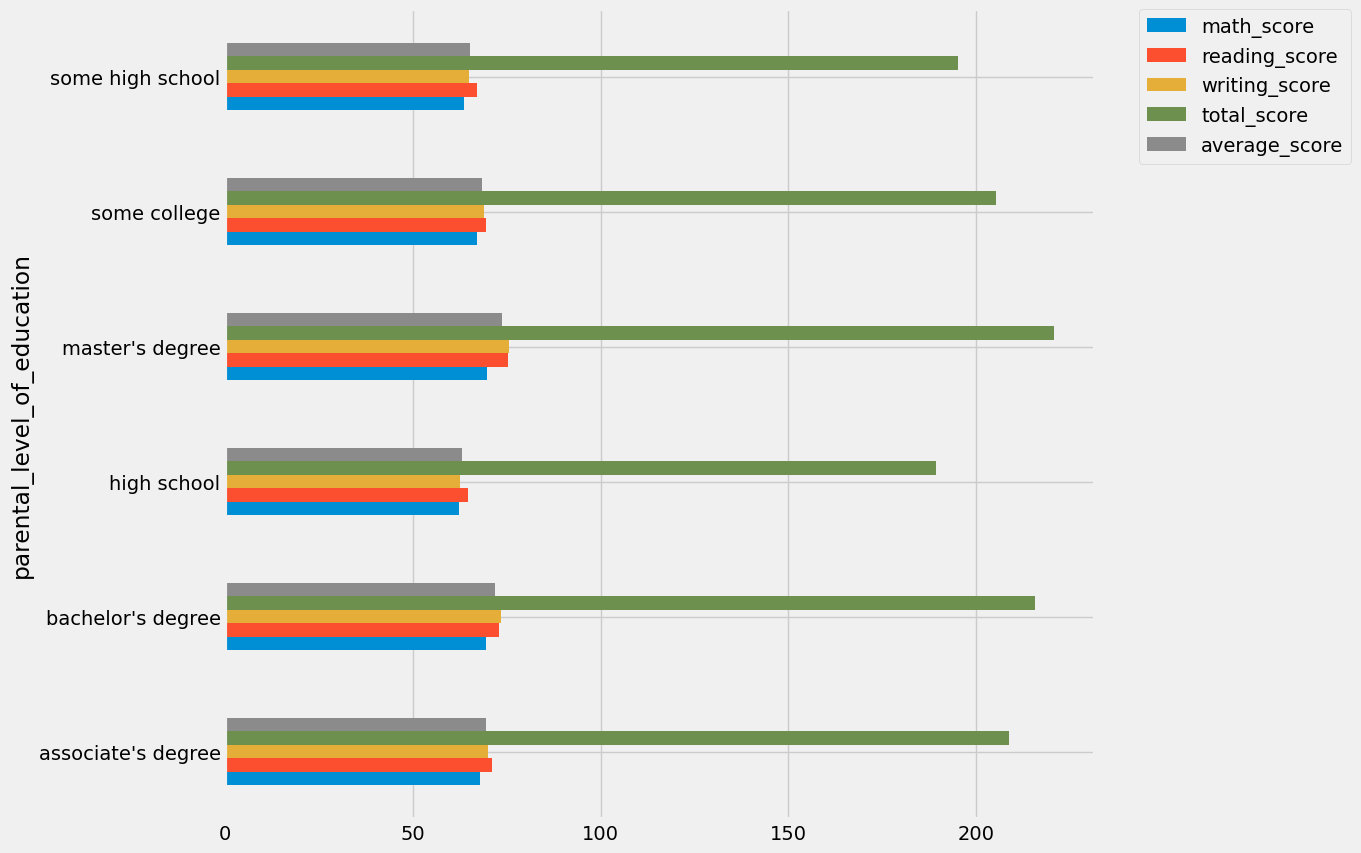

In [84]:
#Bivariate analysis of parental level of education on test scores to identify if parental education has an impact on the test scores of students.
df.groupby('parental_level_of_education').agg('mean',numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

On average, test scores of students whose parents have a bachelor's or master's are higher than other students. 

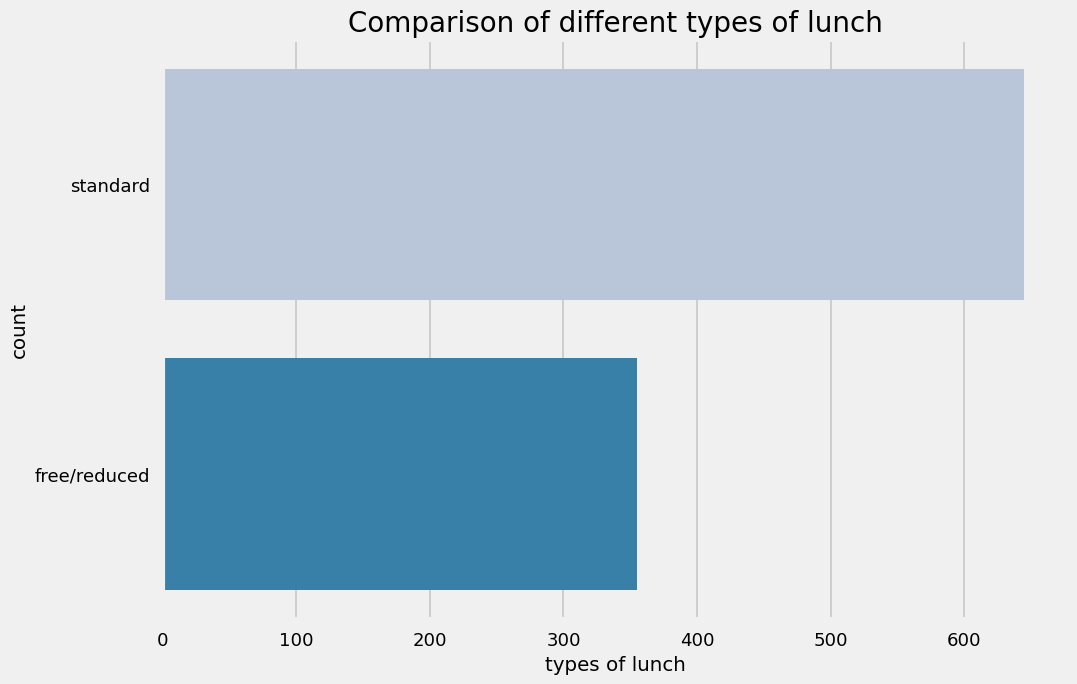

In [86]:
#Univariate anlaysis of lunch type
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['lunch'], palette = 'PuBu')
plt.title('Comparison of different types of lunch', fontweight = 30, fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

More students are served standard lunch than free/reduced lunch

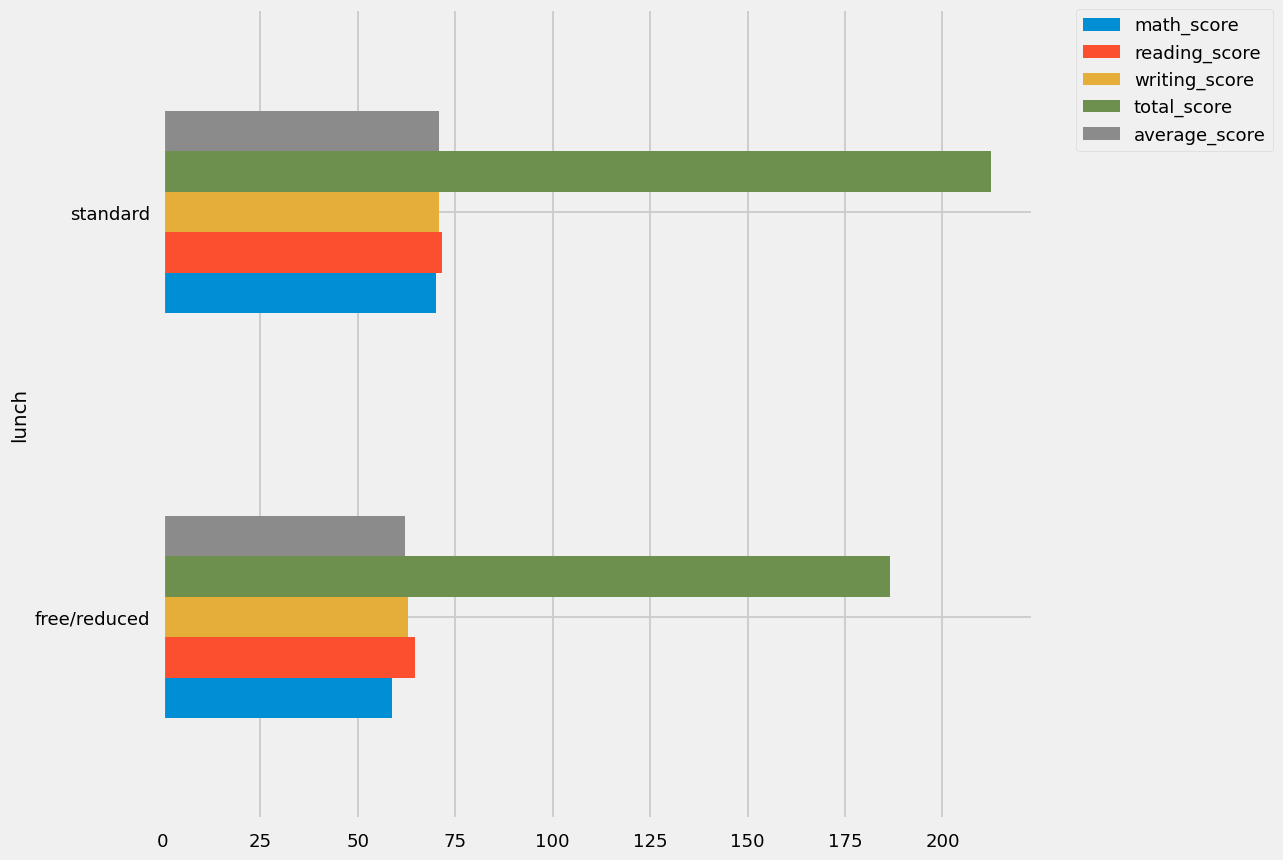

In [89]:
#Bivariate anaysis of lunch type on test scores
df.groupby('lunch').agg('mean',numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

Students who get standard lunch on average tend to perform better than students that recieve free lunch

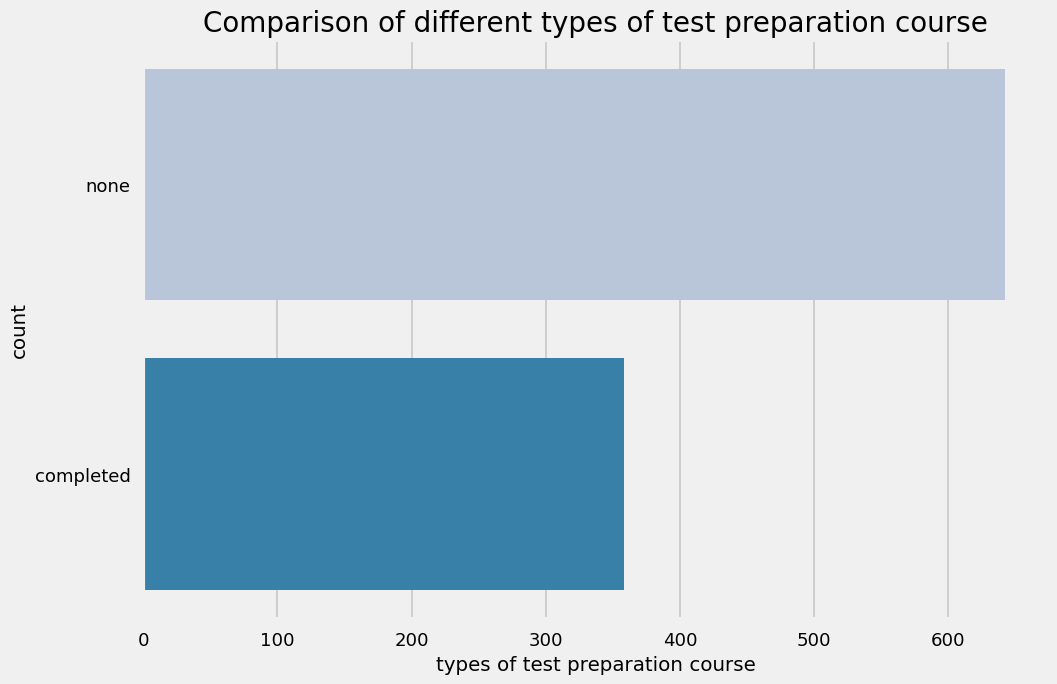

In [90]:
#Univariate analysis of test preparation course
plt.rcParams['figure.figsize'] = (15, 9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(df['test_preparation_course'], palette = 'PuBu')
plt.title('Comparison of different types of test preparation course', fontweight = 30, fontsize = 20)
plt.xlabel('types of test preparation course')
plt.ylabel('count')
plt.show()

Many more students did not complete a test preparation course than did.

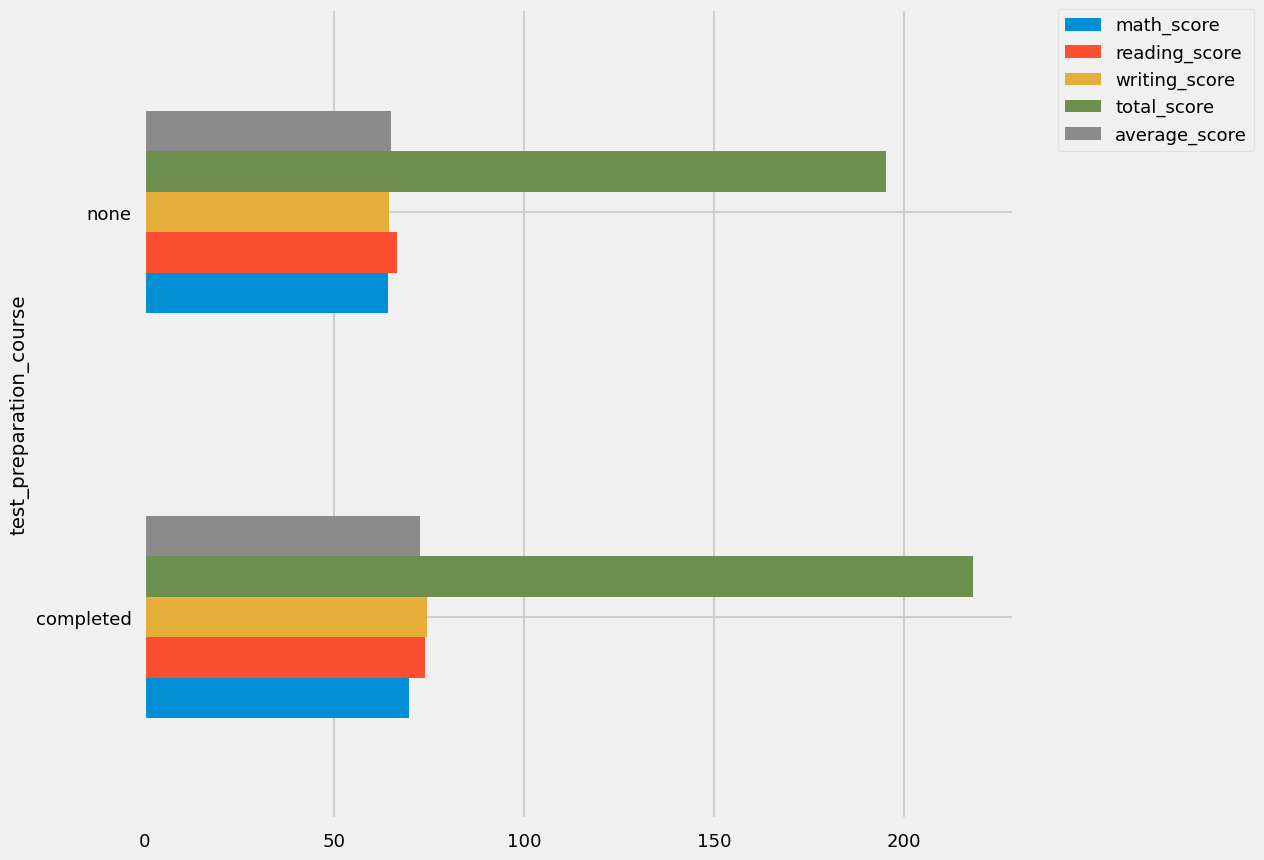

In [91]:
#Bivariate analyis of test preparation course on test scores
df.groupby('test_preparation_course').agg('mean',numeric_only=True).plot(kind='barh',figsize=(10,10))
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show() 

Students that have completed a test preparation course performed better on average in all three categories than those that did not.

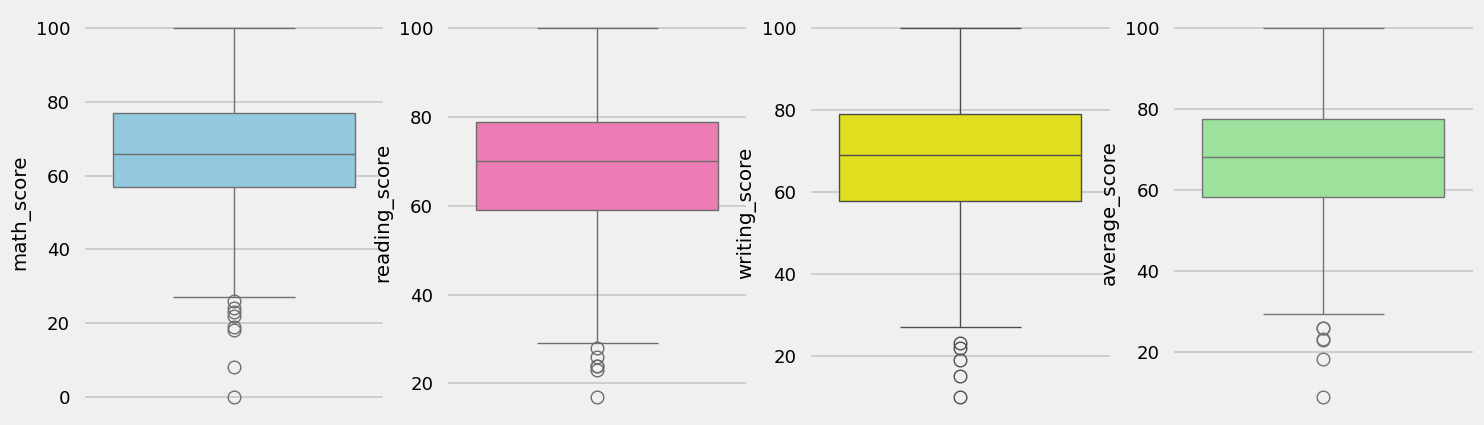

In [93]:
#View Outliers
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

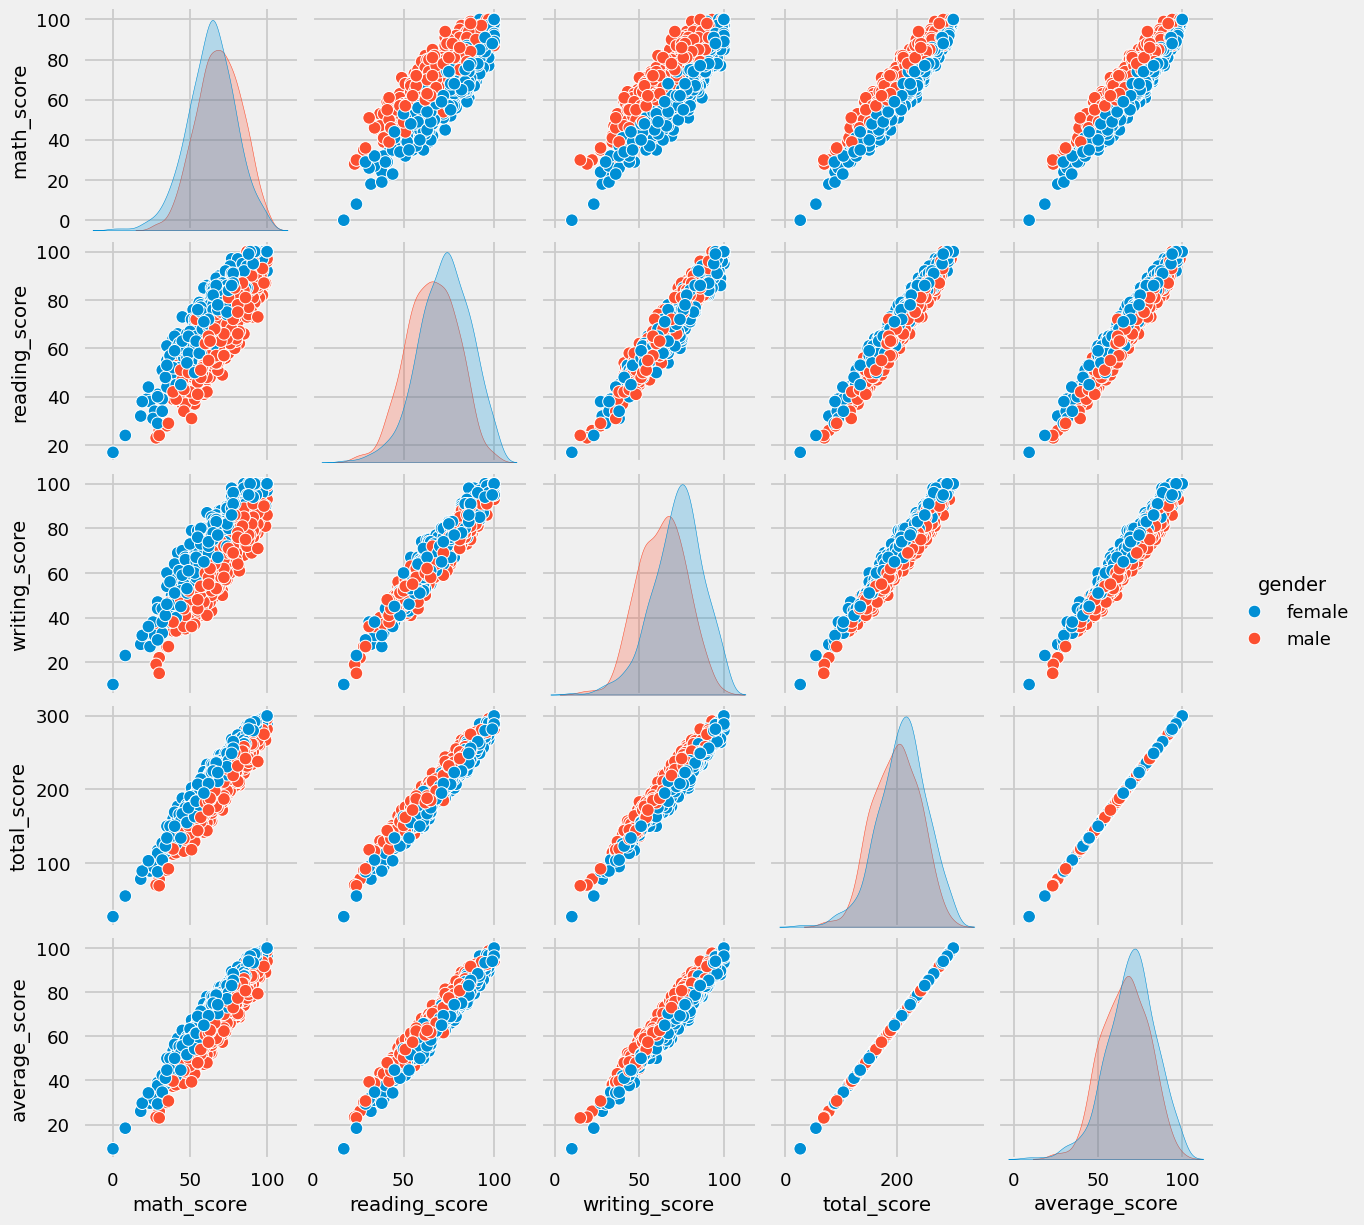

In [ ]:
#Multivariate analysis for numeric data using pairplot
sns.pairplot(df,hue = 'gender')
plt.show()

From the above plot we can see that all test scores increase linearly with each other.

Conclusions:
-Student's performance is realted to lunch, race and parental level of education
-Females lead in pass percentage and are also the top scorers
-Student's perfromance is not strongly correlated with completion of a test preparation course